<a href="https://colab.research.google.com/github/galihtw04/data-science-2026/blob/master/Pertemuan5_Muhammad_Galih_Abdurrahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')

df = sns.load_dataset('tips')

display(df.head())
print("Jumlah data:", df.shape)
display(df.describe().round(2))

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Jumlah data: (244, 7)


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


In [7]:
# =========================
# RATA-RATA TOTAL BILL DAN TIP PER HARI
# =========================

daily_summary = df.groupby('day', observed=False).agg(
    Rata_rata_Total_Bill=('total_bill', 'mean'),
    Rata_rata_Tip=('tip', 'mean'),
    Jumlah_Transaksi=('total_bill', 'count')
).round(2).reset_index()

daily_summary.columns = [
    "Hari",
    "Rata-rata Total Bill (USD)",
    "Rata-rata Tip (USD)",
    "Jumlah Transaksi"
]

display(
    daily_summary.style
    .set_caption("Ringkasan Rata-rata Total Bill dan Tip per Hari")
    .hide(axis="index")
    .format({
        "Rata-rata Total Bill (USD)": "{:.2f}",
        "Rata-rata Tip (USD)": "{:.2f}",
        "Jumlah Transaksi": "{:.0f}"
    })
)

Hari,Rata-rata Total Bill (USD),Rata-rata Tip (USD),Jumlah Transaksi
Thur,17.68,2.77,62
Fri,17.15,2.73,19
Sat,20.44,2.99,87
Sun,21.41,3.26,76


In [5]:
# =========================
# Summary Data
# =========================

summary_data = {
    "Metrik": [
        "Jumlah Transaksi",
        "Rata-rata Total Bill",
        "Median Total Bill",
        "Total Bill Minimum",
        "Total Bill Maksimum",
        "Rata-rata Tip",
        "Korelasi Total Bill dan Tip"
    ],
    "Nilai": [
        len(df),
        round(df['total_bill'].mean(), 2),
        round(df['total_bill'].median(), 2),
        round(df['total_bill'].min(), 2),
        round(df['total_bill'].max(), 2),
        round(df['tip'].mean(), 2),
        round(df['total_bill'].corr(df['tip']), 2)
    ]
}

summary_df = pd.DataFrame(summary_data)

display(
    summary_df.style
    .set_caption("Ringkasan Statistik Dataset Tips")
    .hide(axis="index")
    .format({"Nilai": "{:.2f}"})
    .set_properties(**{
        'text-align': 'left'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [('text-align', 'left')]
        }
    ])
)

Metrik,Nilai
Jumlah Transaksi,244.00
Rata-rata Total Bill,19.79
Median Total Bill,17.80
Total Bill Minimum,3.07
Total Bill Maksimum,50.81
Rata-rata Tip,3.00
Korelasi Total Bill dan Tip,0.68


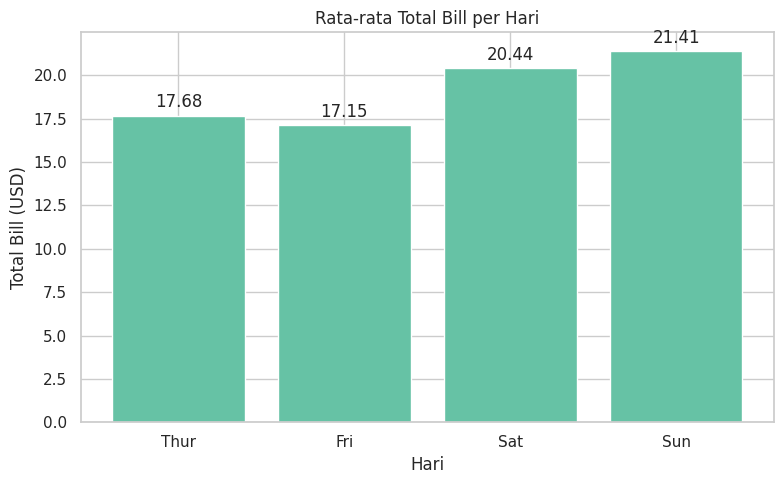

In [6]:
avg_bill_by_day = df.groupby('day', observed=False)['total_bill'].mean().round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_bill_by_day.index.astype(str),
    avg_bill_by_day.values
)

plt.title('Rata-rata Total Bill per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')
plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

### Grafik 1 — Bar Chart Rata-rata Total Bill per Hari

**What?**  
Grafik bar chart menunjukkan rata-rata `total_bill` pelanggan berdasarkan hari. Rata-rata total bill tertinggi terjadi pada hari Minggu sebesar sekitar **21,41 USD**, sedangkan yang terendah terjadi pada hari Jumat sekitar **17,15 USD**. Hari Sabtu juga cukup tinggi dengan rata-rata sekitar **20,44 USD**.

**So what?**  
Data ini menunjukkan bahwa transaksi pelanggan cenderung lebih besar pada akhir pekan, terutama hari Minggu dan Sabtu. Hal ini kemungkinan terjadi karena pelanggan datang dalam kelompok yang lebih besar atau melakukan aktivitas makan bersama keluarga pada akhir pekan.

**Now what?**  
Restoran dapat menyiapkan stok bahan makanan dan jumlah staf lebih banyak pada akhir pekan. Analisis lanjutan dapat dilakukan dengan membandingkan jumlah pelanggan (`size`) pada hari Sabtu dan Minggu untuk memastikan apakah tagihan tinggi dipengaruhi oleh jumlah orang dalam satu meja.

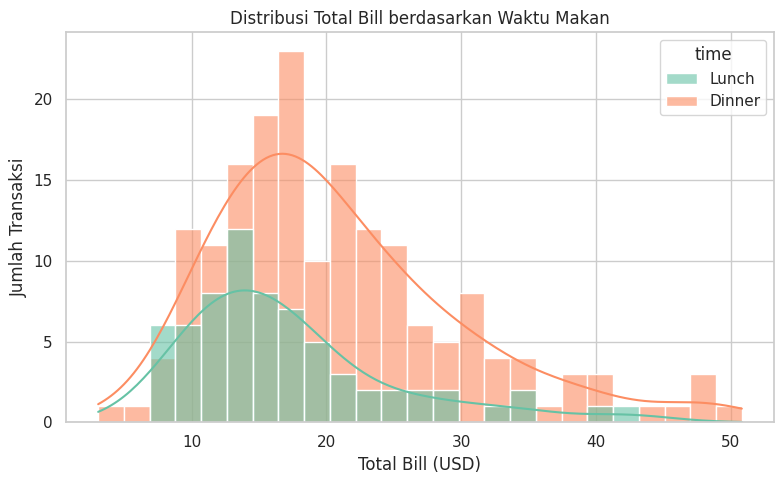

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='total_bill',
    hue='time',
    kde=True,
    bins=25,
    alpha=0.6
)

plt.title('Distribusi Total Bill berdasarkan Waktu Makan')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Jumlah Transaksi')

plt.tight_layout()
plt.show()

Grafik 2 — Histogram Distribusi Total Bill
What?

Histogram ini menunjukkan sebaran total_bill dari total 244 transaksi pada dataset. Namun, sumbu Y pada grafik tidak menunjukkan total 244 secara langsung, melainkan jumlah transaksi pada setiap rentang nilai total_bill. Dari grafik terlihat bahwa rentang total bill sekitar 10 sampai 25 USD memiliki jumlah transaksi paling banyak, dengan puncak frekuensi per rentang berada di kisaran 20-an transaksi. Nilai total bill terkecil adalah 3,07 USD, sedangkan nilai terbesar mencapai 50,81 USD.

So what?

Hal ini menunjukkan bahwa mayoritas transaksi restoran berada pada nilai kecil sampai menengah, bukan transaksi besar. Transaksi dinner terlihat lebih dominan dibanding lunch, terutama pada rentang total bill menengah hingga tinggi. Artinya, pelanggan saat dinner cenderung lebih banyak atau memiliki nilai tagihan yang lebih besar dibanding lunch.

Now what?

Restoran dapat fokus membuat strategi peningkatan penjualan pada jam dinner karena aktivitas transaksi terlihat lebih tinggi. Untuk lunch, restoran bisa membuat promo paket makan siang agar jumlah transaksi dan nilai total bill meningkat. Analisis lanjutan dapat dilakukan dengan membandingkan rata-rata total_bill antara lunch dan dinner secara langsung.

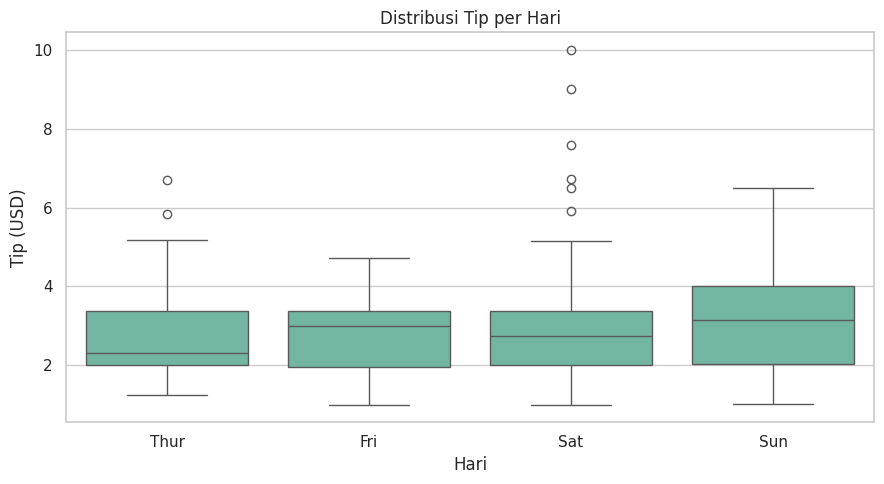

,day,jumlah_transaksi,rata_rata_tip,median_tip,tip_minimum,tip_maksimum
0,Thur,62,2.77,2.30,1.25,6.70
1,Fri,19,2.73,3.00,1.00,4.73
2,Sat,87,2.99,2.75,1.00,10.00
3,Sun,76,3.26,3.15,1.01,6.50


In [9]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='day',
    y='tip',
    order=['Thur', 'Fri', 'Sat', 'Sun']
)

plt.title('Distribusi Tip per Hari')
plt.xlabel('Hari')
plt.ylabel('Tip (USD)')

plt.tight_layout()
plt.show()
tip_summary = df.groupby('day', observed=False).agg(
    jumlah_transaksi=('tip', 'count'),
    rata_rata_tip=('tip', 'mean'),
    median_tip=('tip', 'median'),
    tip_minimum=('tip', 'min'),
    tip_maksimum=('tip', 'max')
).round(2).reset_index()

tip_summary

### Grafik 3 — Boxplot Distribusi Tip per Hari

**What?**  
Boxplot ini menunjukkan distribusi nilai `tip` berdasarkan hari. Rata-rata tip keseluruhan pada dataset adalah sekitar **3,00 USD**. Berdasarkan ringkasan per hari, rata-rata tip tertinggi terjadi pada hari **Minggu sekitar 3,26 USD**, sedangkan rata-rata tip terendah terjadi pada hari **Jumat sekitar 2,73 USD**. Pada grafik juga terlihat beberapa outlier, yaitu nilai tip yang jauh lebih tinggi dibanding mayoritas transaksi lainnya.

**So what?**  
Distribusi ini menunjukkan bahwa nilai tip pelanggan berbeda pada setiap hari. Hari Minggu memiliki nilai tip yang lebih tinggi karena kemungkinan pelanggan datang dalam kelompok lebih besar atau memiliki total tagihan yang lebih tinggi. Hari Jumat memiliki transaksi lebih sedikit dan rata-rata tip lebih rendah, sehingga kontribusinya terhadap total tip juga lebih kecil.

**Now what?**  
Restoran dapat memberi perhatian lebih pada hari Minggu karena potensi tip dan nilai transaksi lebih tinggi. Manajemen juga dapat mengevaluasi strategi pelayanan pada hari Jumat agar nilai transaksi dan tip meningkat. Analisis lanjutan dapat dilakukan dengan membandingkan `tip`, `total_bill`, dan `size` untuk mengetahui apakah tip tinggi dipengaruhi oleh besar tagihan atau jumlah pelanggan dalam satu meja.

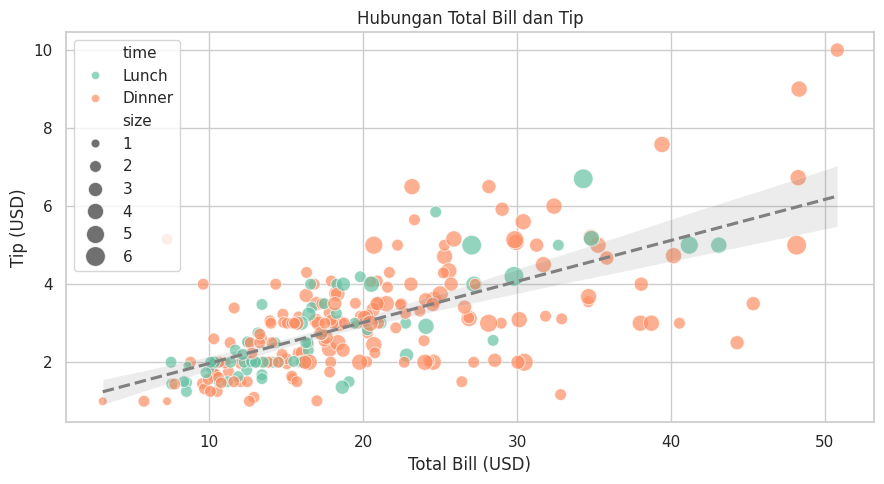

Korelasi total_bill dan tip: 0.68


,time,jumlah_transaksi,rata_rata_total_bill,rata_rata_tip,rata_rata_size
0,Lunch,68,17.17,2.73,2.41
1,Dinner,176,20.80,3.10,2.63


In [10]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='time',
    size='size',
    sizes=(40, 200),
    alpha=0.7
)

sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--'}
)

plt.title('Hubungan Total Bill dan Tip')
plt.xlabel('Total Bill (USD)')
plt.ylabel('Tip (USD)')

plt.tight_layout()
plt.show()
corr_totalbill_tip = df['total_bill'].corr(df['tip']).round(2)

relation_summary = df.groupby('time', observed=False).agg(
    jumlah_transaksi=('total_bill', 'count'),
    rata_rata_total_bill=('total_bill', 'mean'),
    rata_rata_tip=('tip', 'mean'),
    rata_rata_size=('size', 'mean')
).round(2).reset_index()

print("Korelasi total_bill dan tip:", corr_totalbill_tip)
relation_summary

### Grafik 4 — Scatter Plot Hubungan Total Bill dan Tip

**What?**  
Scatter plot ini menunjukkan hubungan antara `total_bill` dan `tip`. Setiap titik merepresentasikan satu transaksi, warna menunjukkan waktu makan (`Lunch` atau `Dinner`), dan ukuran titik menunjukkan jumlah pelanggan dalam satu meja (`size`). Terlihat pola hubungan positif, yaitu semakin tinggi total bill maka nilai tip cenderung ikut meningkat. Nilai korelasi antara `total_bill` dan `tip` adalah sekitar **0,68**, yang menunjukkan hubungan positif cukup kuat.

**So what?**  
Pola ini penting karena menunjukkan bahwa besar kecilnya tip cukup dipengaruhi oleh total tagihan pelanggan. Transaksi dengan total bill besar banyak muncul pada waktu dinner, sehingga dinner menjadi waktu makan yang berpotensi menghasilkan tip lebih besar. Namun, beberapa titik tidak sepenuhnya mengikuti garis tren, artinya tip tidak hanya dipengaruhi oleh total bill, tetapi juga bisa dipengaruhi oleh kualitas layanan, jumlah pelanggan, atau kebiasaan pelanggan.

**Now what?**  
Restoran dapat meningkatkan strategi pelayanan dan penjualan pada waktu dinner karena transaksi bernilai tinggi lebih banyak terlihat pada waktu tersebut. Selain itu, restoran dapat mendorong peningkatan total bill melalui menu paket, rekomendasi menu tambahan, atau pelayanan yang lebih baik. Analisis lanjutan dapat dilakukan dengan menghitung persentase tip terhadap total bill untuk mengetahui apakah pelanggan dengan tagihan besar juga memberikan proporsi tip yang lebih tinggi.